1. Introduction to the course & Digital transformation of the en
ergy sector [4pt]

Tips: Inspect and understand provided datasets (variables, units, resolution, etc.). Work
with train
test.csv file that includes several variables such as timestamp, demand, price,
PV, and weather-related data.

1. Produce a data dictionary for your file: for every variable give its unit, sampling
resolution, observed range, etc.
2. Visualize PV generation, demand, and electricity price over a few days.
3. Before plotting, write down two expectations: when during the day you expect PV to
peak, and when you expect demand to peak. After plotting, state which expectation
was wrong and what specifically in your data corrected you.
4. Research how digitalization transforms household energy, and name one thing in your
own dataset that would not have existed twenty years ago.
5. Briefly explain in your own words the idea behind working with solar generation data.
(a) Why is it important?
(b) How can it be used in private and business sectors?

In [1]:
import pandas as pd

#Load dataset
df=pd.read_csv("266050_training.csv")
print("Dataset shape:", df.shape)

#Variables with units
print("Variables:")
print(df.columns.tolist())
#Five first rows
df.head()



Dataset shape: (8759, 18)
Variables:
['timestamp', 'pv_mod1', 'pv_mod2', 'pv_mod3', 'Demand', 'pv', 'Price', 'Temperature', 'Pressure (hPa)', 'Cloud_cover (%)', 'Cloud_cover_low (%)', 'Cloud_cover_mid (%)', 'Cloud_cover_high (%)', 'Wind_speed_10m (km/h)', 'Shortwave_radiation (W/m²)', 'direct_radiation (W/m²)', 'diffuse_radiation (W/m²)', 'direct_normal_irradiance (W/m²)']


,timestamp,pv_mod1,pv_mod2,pv_mod3,Demand,pv,Price,Temperature,Pressure (hPa),Cloud_cover (%),Cloud_cover_low (%),Cloud_cover_mid (%),Cloud_cover_high (%),Wind_speed_10m (km/h),Shortwave_radiation (W/m²),direct_radiation (W/m²),diffuse_radiation (W/m²),direct_normal_irradiance (W/m²)
0,2013-07-01 00:00:00+00:00,0.0,0.0,0.0,0.270,0.0,0.01605,13.5,1011.3,4,0,0,3,10.5,NaN,0,0,0.0
1,2013-07-01 01:00:00+00:00,0.0,0.0,0.0,0.236,0.0,0.00095,13.2,1010.8,27,1,2,23,11.9,NaN,0,0,0.0
2,2013-07-01 02:00:00+00:00,0.0,0.0,0.0,0.270,0.0,0.00060,13.1,1010.3,33,0,0,32,11.6,NaN,0,0,0.0
3,2013-07-01 03:00:00+00:00,0.0,0.0,0.0,0.273,0.0,0.00046,13.0,1010.3,28,0,0,27,11.2,9.0,2,7,30.1
4,2013-07-01 04:00:00+00:00,0.0,0.0,0.0,0.302,0.0,0.00046,13.8,1010.2,16,0,1,14,11.7,NaN,30,31,252.0


In [2]:
#Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])
print("Start time period :", df["timestamp"].min())
print("End time period:  ", df["timestamp"].max())

# Sampling resolution
sampling_resolution = df["timestamp"].sort_values().diff().mode()[0]
print("\nSampling resolution:", sampling_resolution)

#Show column names and datatypes
print("\n Info:")
df.info()

Start time period : 2013-07-01 00:00:00+00:00
End time period:   2014-06-30 23:00:00+00:00

Sampling resolution: 0 days 01:00:00

 Info:
<class 'pandas.DataFrame'>
RangeIndex: 8759 entries, 0 to 8758
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype              
---  ------                           --------------  -----              
 0   timestamp                        8759 non-null   datetime64[us, UTC]
 1   pv_mod1                          8322 non-null   float64            
 2   pv_mod2                          8263 non-null   float64            
 3   pv_mod3                          8249 non-null   float64            
 4   Demand                           8759 non-null   float64            
 5   pv                               8759 non-null   float64            
 6   Price                            8759 non-null   float64            
 7   Temperature                      8759 non-null   float64            
 8   Pressure (hPa)        

In [3]:
# Create data dictionary
data_dictionary = []

for col in df.columns:
    
    if col == "timestamp":
        observed_range = f"{df[col].min()} to {df[col].max()}"
        
    elif pd.api.types.is_numeric_dtype(df[col]):
        observed_range = f"{df[col].min():.2f} to {df[col].max():.2f}"
        
    else:
        observed_range = f"{df[col].nunique()} unique values"

    data_dictionary.append({
        "Variable": col,
        "Data type": str(df[col].dtype),
        "Sampling resolution": str(sampling_resolution),
        "Observed range": observed_range,
        "Non-null values": df[col].count(),
        "Missing values": df[col].isna().sum()
    })

data_dictionary = pd.DataFrame(data_dictionary)

display(data_dictionary)

,Variable,Data type,Sampling resolution,Observed range,Non-null values,Missing values
0,timestamp,"datetime64[us, UTC]",0 days 01:00:00,2013-07-01 00:00:00+00:00 to 2014-06-30 23:00:...,8759,0
1,pv_mod1,float64,0 days 01:00:00,0.00 to 4.97,8322,437
2,pv_mod2,float64,0 days 01:00:00,0.00 to 4.61,8263,496
3,pv_mod3,float64,0 days 01:00:00,0.00 to 4.97,8249,510
4,Demand,float64,0 days 01:00:00,0.00 to 4.14,8759,0
5,pv,float64,0 days 01:00:00,0.00 to 4.97,8759,0
6,Price,float64,0 days 01:00:00,0.00 to 0.26,8759,0
7,Temperature,float64,0 days 01:00:00,-18.30 to 28.90,8759,0
8,Pressure (hPa),float64,0 days 01:00:00,971.70 to 1041.00,8759,0
9,Cloud_cover (%),int64,0 days 01:00:00,0.00 to 100.00,8759,0


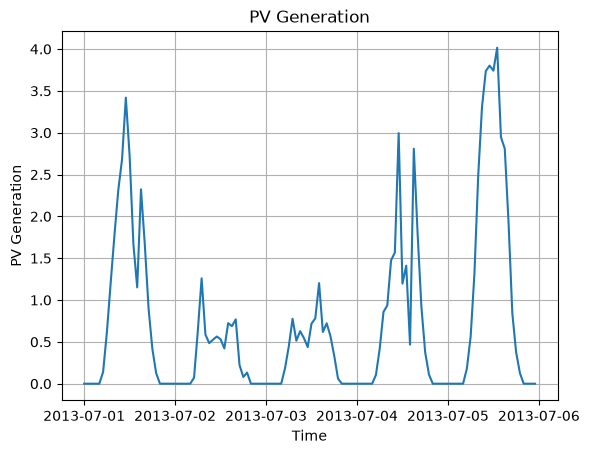

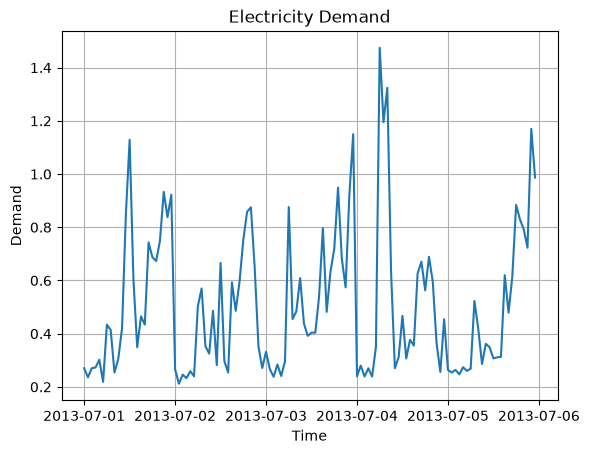

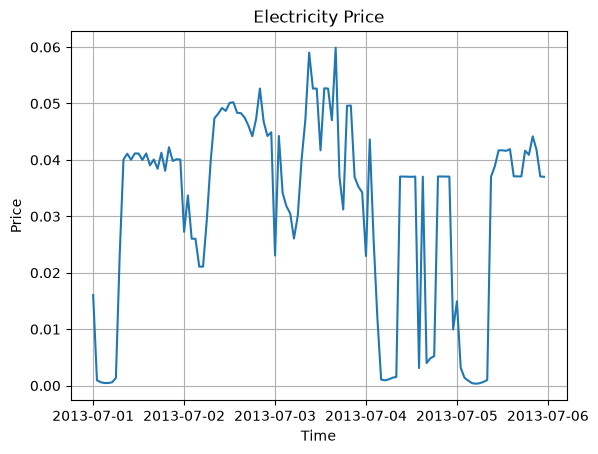

In [4]:
#plot PV generation, electricity demand, electrisity price
import matplotlib.pyplot as plt

#convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Lets select for example 5 days
start_date = "2013-07-01"
end_date   = "2013-07-06"

df_few_days = df[
    (df["timestamp"] >= start_date) &
    (df["timestamp"] < end_date)
]

# 1. PV generation
plt.figure()
plt.plot(df_few_days["timestamp"], df_few_days["pv"])
plt.title("PV Generation")
plt.xlabel("Time")
plt.ylabel("PV Generation")
plt.grid(True)
plt.show()

# 2. Electricity demand
plt.figure()
plt.plot(df_few_days["timestamp"], df_few_days["Demand"])
plt.title("Electricity Demand")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.grid(True)
plt.show()

# 3. Electricity price
plt.figure()
plt.plot(df_few_days["timestamp"], df_few_days["Price"])
plt.title("Electricity Price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.grid(True)
plt.show()

My two expectations before plotting were:

**Expectation 1:** The peak of PV generation is around midday, 12:00–15:00, when solar activity is more intense.

**Expectation 2:** Electricity demand will likely peak in the morning, around 6:00–8:00, when people wake up and prepare going to  work or school.

However, from results below we can see:

**My Expectation 1** was correct and PV generation peak is around 12:00. 

**My expectation 2** about demand peak was wrong, because peak occurs around 19:00 in the evening, not in the morning according to the training data.

In [5]:
# Extract hour from timestamp
df["hour"] = df["timestamp"].dt.hour

# Average PV and demand for each hour
hourly_profile = df.groupby("hour")[["pv", "Demand"]].mean()

display(hourly_profile)

print("PV peak hour:")
print(hourly_profile["pv"].idxmax())

print("Demand peak hour:")
print(hourly_profile["Demand"].idxmax())

,pv,Demand
hour,,
0,0.000000,0.348082
1,0.000000,0.299822
2,0.000000,0.291263
3,0.000000,0.284230
4,0.000274,0.283118
5,0.031085,0.306871
6,0.169030,0.396079
7,0.543701,0.578364
8,1.077115,0.675482


PV peak hour:
12
Demand peak hour:
19


**4. Digitization and household energy**

**Digitalisation is transforming household energy from passive consumption into active energy management.** For example, a household can charge an electric vehicle or heat water when electricity is cheaper or when its own solar panels are producing electricity. Smart meters and solar panels allow households to monitor consumption and adjust when they consume or produce electricity.

**Twenty years ago the detailed hourly digital data combining electricity demand, electricity price, PV generation and weather variables was not available.** Smart and remotely read meters have made consumption data much more accessible.

**5. Why work with solar-generation data?**

(a) Why is it important?

Solar generation depends strongly on time of day. Analysing historical PV data together with weather, demand and price helps us understand these patterns and forecast future generation. Better forecasts make it easier to balance electricity supply and demand.

(b) How can it be used in private and business sectors?

For private households, solar-generation data can help decide when to use appliances/charge electric car, store electricity in a battery or sell electricity to the grid. 

For businesses, it can be used for electricity consumption cost optimization. For example, a company could shift flexible electricity consumption toward hours when its PV production is high, reducing the amount of electricity purchased from the grid.

**2. Anatomy of your time series**

Tips: Work with demand in train -test.csv. Decompose it into trend (Tt), seasonality (St), and residuals (Rt).

1. Do the step-by-step additive classical decomposition (yt = Tt+St+Rt). Describe each
component.
2. Before looking at the result, predict in one sentence during which months or weeks the
seasonal effect will be strongest, and give your reason. Then compare with what the
decomposition shows and explain any difference.
3. Create typical demand profiles (e.g., average day, weekday vs. weekend) and explain
the methodology used to derive them.
4. Which of the three components carries the most variance in your series? What does
that imply about how hard this series will be to work with?

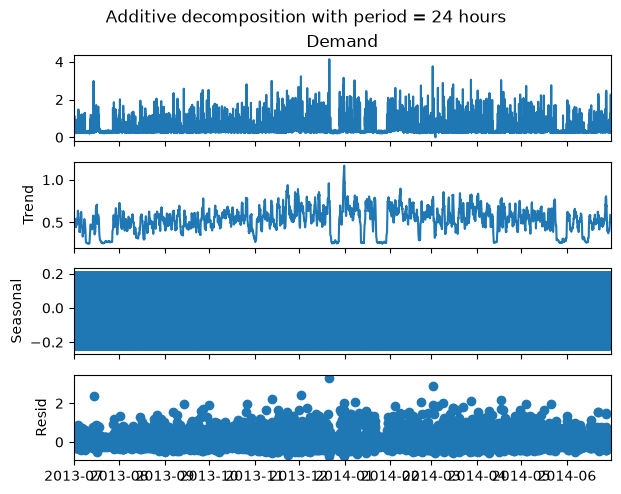

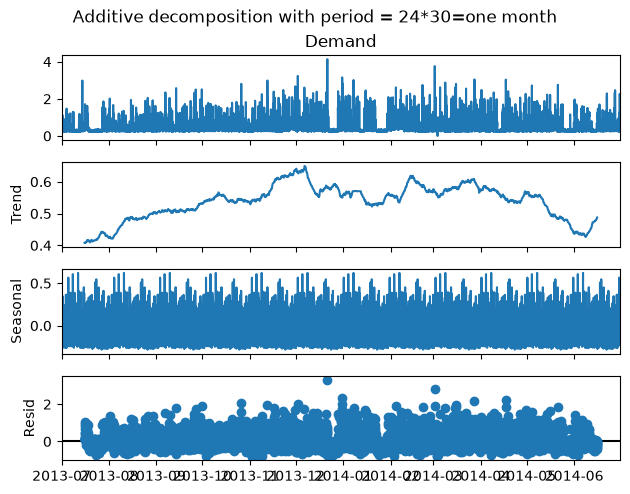

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Make timestamp the index
demand = df[["timestamp", "Demand"]].copy()
demand = demand.set_index("timestamp")

#Classical decomposition using period=24hours (code reused from Practical_03_times_series lab)
daily_decomposition = seasonal_decompose(demand["Demand"], model="additive", period=24 )
daily_decomposition.plot()
plt.suptitle("Additive decomposition with period = 24 hours", y=1.02)
plt.show()


#Classical decomposition using period=24hours*30=1 month (code reused from Practical_03_times_series lab)
daily_decomposition = seasonal_decompose(demand["Demand"], model="additive", period=24*30 )
daily_decomposition.plot()
plt.suptitle("Additive decomposition with period = 24*30=one month", y=1.02)
plt.show()

2.1. Since the dataset has hourly observations, I used a seasonal period of 24 hours. 

**The trend** represents slower changes in the overall demand level. 

**The seasonal component** represents the recurring daily demand pattern, 

**the residual component** contains variation that is not explained by the trend or daily seasonality.

2.2. **Before decomposition:** I expected the seasonal effect to be strongest during the winter months, because colder temperatures should increase electricity demand.

**After decomposition:** The MONTHLY decomposition does not clearly support my expectation. The seasonal component appears to have approximately the same amplitude throughout the year. The trend component, however, changes considerably over time, increasing from summer 2013 and reaching a high level around December–January before decreasing towards summer 2014. This suggests that the higher winter demand is captured mainly by the trend.

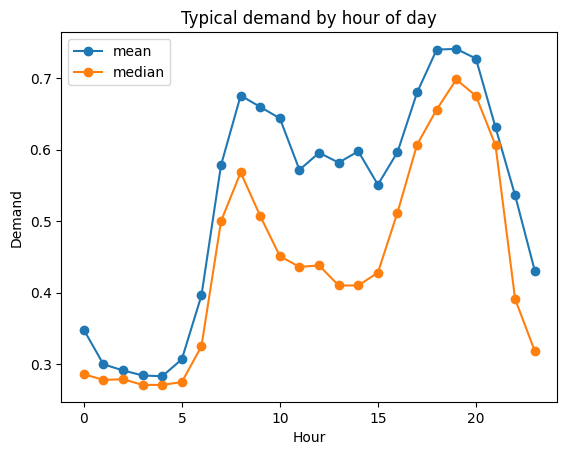

In [ ]:
# Typical average day (code reused from Practical_03_times_series lab)
hourly_profile = df.groupby(df["timestamp"].dt.hour)["Demand"].agg(["mean", "median"])

hourly_profile.plot(
    title="Typical demand by hour of day",
    xlabel="Hour",
    ylabel="Demand",
    marker="o"
)

plt.show()

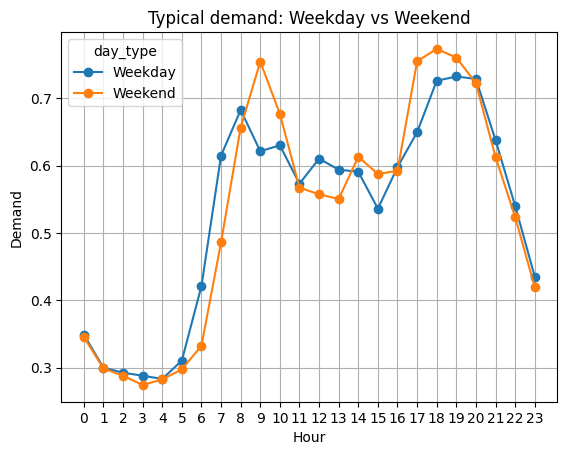

In [ ]:
##Typical demand: Weekday vs Weekend (code reused from Practical_03_times_series lab)

df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek

df["day_type"] = df["day_of_week"].apply(
    lambda x: "Weekday" if x < 5 else "Weekend"
)

weekday_weekend_profile = (
    df.groupby(["hour", "day_type"])["Demand"]
      .mean()
      .unstack()
)

weekday_weekend_profile.plot(
    title="Typical demand: Weekday vs Weekend",
    xlabel="Hour",
    ylabel="Demand",
    marker="o"
)

plt.xticks(range(24))
plt.grid()
plt.show()

**2.3 Methodology explanation:** Following the aggregation approach used in Practical 03, 

I grouped the hourly demand observations by hour of day 
and calculated the mean and median demand for each hour to obtain a typical daily profile. 

I then used the day-of-week information from the timestamp to classify observations as weekdays (Monday–Friday) or weekends (Saturday–Sunday). 
Finally, I calculated mean demand for each hour separately for weekdays and weekends and compared the resulting 24-hour profiles.

**2.4 Which of the three components carries the most variance in your series?**

 By observing the decomposition plot, the residual component appears to carry the most variance. 
 
 It shows much larger and more irregular fluctuations than the trend and seasonal components. This implies that electricity demand may be relatively difficult to model and forecast, because a substantial part of its variation is not explained by regular trend or seasonal patterns.

**Task 3**
1. Create a project plan diagram (flowchart) specific to the received dataset, using the
data science lifecycle framework.
2. Based on the received dataset, where do you expect the most effort (cleaning, feature
engineering, modelling, etc.) in your plan? Support the answer with an observation
from Task 1 or Task 2.
3. Identify whether any additional external data sources are required for the analysis or
not

3.1. My project plan follows the Data Science Lifecycle introduced in Lecture 4. The main stages are: Business Understanding → Data Collection → Data Cleaning → Data Exploration → Feature Engineering → Modelling → Data Visualisation. Since this is an iterative process, I may return to earlier stages if problems are discovered during modelling or evaluation.

3.2.I expect most effort to be required in data cleaning and feature engineering, followed by modelling. This expectation is supported by my analysis in Task 1, where I found missing values in several variables. In particular, Shortwave_radiation contains 7,095 missing values. Also pv_mod1, pv_mod2, and pv_mod3 also contain missing observations. Therefore, the missing-data problem needs to be investigated before modelling. Feature engineering will also require effort because the dataset is hourly time-series data, so features such as hour, day, and rolling statistics may be useful for forecasting.

3.3. No additional external data seems currently needed, because the dataset already contains demand, PV generation, price and detailed weather variables. Maybe, calendar information such as public holidays could be added.

